# Sprint 2 – Data Understanding

## Objetivo

El propósito de este notebook es comprender la estructura, contenido y calidad del conjunto de datos antes de iniciar el proceso de limpieza y análisis.

Durante este sprint se realizará una exploración inicial del dataset para identificar el tipo de variables, posibles problemas de calidad, valores faltantes, registros duplicados y características generales de la información.

Los hallazgos obtenidos servirán como base para las actividades de preparación de datos del siguiente sprint.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mostrar todas las columnas
pd.set_option("display.max_columns", None)

# Mostrar hasta 100 filas cuando sea necesario
pd.set_option("display.max_rows", 100)

In [17]:
df = pd.read_csv("../data/raw/Sample - Superstore.csv", encoding="latin1")


In [18]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [19]:
#revisamos la cantidad de filas y de columnas del dataframe
df.shape

(9994, 21)

¿Cuántas filas? contiene 9994
¿Cuántas columnas? 21

Dimensiones del dataset

El conjunto de datos está compuesto por 9,994 registros y 21 variables.

Cada registro representa una línea de detalle de una orden de venta, lo que implica que un mismo pedido puede contener múltiples registros cuando incluye varios productos.

El volumen de información es suficiente para realizar un análisis descriptivo representativo del comportamiento comercial de la empresa.

En esta etapa no se identifican limitaciones relacionadas con el tamaño del dataset.

In [50]:
df.head(30)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700




¿Qué representa cada fila?
Cada fila representa una línea de producto asociada a un pedido realizado por un cliente. Un mismo pedido puede contener varios productos, por lo que un mismo `Order ID` puede aparecer en diferentes filas
¿Qué observas a primera vista?
A primera vista, el dataset contiene información relacionada con pedidos, clientes, productos, ubicación geográfica y resultados comerciales. Se observan variables importantes para el análisis como `Sales`, `Quantity`, `Discount` y `Profit`, que permitirán analizar el desempeño de las ventas y la rentabilidad.

También se observan columnas de fecha como `Order Date` y `Ship Date`, que posteriormente podrían utilizarse para analizar la evolución de las ventas a través del tiempo.

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

Cuántas columnas son object? no contiene tipo object
¿Cuántas son numéricas? 6 numericas, 3 de tipo float y 3 de tipo inteyer
¿Hay fechas? si hay fechas, pero no estan en el tipo de dato correcto, estan en string

In [52]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Ventas máximas: $22,638.48

El pedido con mayor valor alcanzó $22,638.48, una cifra muy superior al promedio de ventas. Esto indica la existencia de pedidos excepcionalmente grandes (outliers) que pueden estar asociados a clientes corporativos, compras por volumen o productos de alto valor. Conviene analizar estas transacciones por separado para identificar oportunidades de replicar ese tipo de ventas.

Ventas promedio: $229.86

En promedio, cada pedido genera $229.86 en ventas. Sin embargo, al compararlo con la venta máxima se observa una gran diferencia, lo que sugiere una distribución sesgada hacia la derecha: la mayoría de las ventas son relativamente pequeñas y unas pocas operaciones de gran valor elevan el promedio. Sería recomendable complementar este indicador con la mediana ($54.49) para representar mejor el comportamiento típico de los pedidos.

 Profit promedio: $28.66

Cada venta genera, en promedio, una utilidad de $28.66. Considerando que el ticket promedio es de $229.86, el margen promedio de utilidad es relativamente reducido. Además, el dataset contiene valores negativos de profit (hasta -$6,599.98), lo que indica que algunas ventas generan pérdidas, probablemente debido a descuentos elevados o costos asociados.

 Descuento promedio: 15.62%

El descuento promedio aplicado es de 15.62%, lo que indica que una parte importante de las ventas se realiza con promociones. Aunque los descuentos pueden impulsar el volumen de ventas, también pueden afectar la rentabilidad. Por ello, resulta importante analizar la relación entre el porcentaje de descuento y el profit para determinar si existen niveles de descuento que reduzcan significativamente las ganancias.

 Insights de negocio
Existen ventas extraordinariamente altas que representan oportunidades para identificar clientes o segmentos de alto valor.
El ticket promedio es considerablemente mayor que la mediana, lo que evidencia una distribución con valores atípicos.
La rentabilidad promedio es positiva, pero la presencia de pérdidas importantes sugiere revisar la estrategia comercial en determinadas operaciones.
El descuento promedio del 15.62% indica una fuerte utilización de promociones; conviene evaluar si estos descuentos realmente incrementan la utilidad o únicamente el volumen de ventas.

Estos hallazgos pueden servir como introducción al análisis exploratorio (EDA) y justificar análisis posteriores, como la distribución de ventas, el impacto de los descuentos sobre la utilidad y la identificación de clientes o productos más rentables.

In [53]:
df.dtypes


Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

¿Qué columnas deberían convertirse a fecha?
Order Date
Ship Date

¿Qué columnas son categóricas?
country
city
State
 Region 
category
Sub-category
como observacion considero que estas variables de tipo string deberian ser category o object 

In [54]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [55]:
(df.isnull().sum()/len(df))*100

Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
State            0.0
Postal Code      0.0
Region           0.0
Product ID       0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Sales            0.0
Quantity         0.0
Discount         0.0
Profit           0.0
dtype: float64

### Valores nulos

Se realizó una revisión de valores nulos en el dataset utilizando
`df.isnull().sum()`.

No se identificaron valores nulos en ninguna de las columnas, por lo que
no es necesario realizar imputaciones o eliminación de registros por datos
faltantes en esta etapa.

Sin embargo, se continuará evaluando la calidad de los datos mediante la
búsqueda de duplicados, inconsistencias, tipos de datos incorrectos y
valores atípicos.

In [56]:
df.duplicated().sum()
df[df.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


### Revisión de duplicados

Se realizó una revisión de registros duplicados utilizando
`df.duplicated().sum()`.

El resultado fue de **0 registros duplicados**, por lo que no es necesario
eliminar filas por duplicidad en esta etapa del análisis.

Esto indica que cada registro del dataset presenta al menos una diferencia
respecto a los demás registros.

In [57]:
df.nunique()


Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

## Primeras observaciones del dataset

El dataset contiene información correspondiente a:

- **793 clientes diferentes**
- **1,850 productos diferentes**
- **531 ciudades**
- **49 estados**

Al comparar la cantidad de clientes con el número de órdenes registradas,
se observa que existen múltiples compras asociadas a una misma base de clientes.

Este comportamiento podría indicar la presencia de clientes recurrentes;
sin embargo, todavía no es suficiente para afirmar que existe una alta
fidelización. Para comprobarlo sería necesario analizar la frecuencia de
compra por cliente, el porcentaje de clientes recurrentes y el tiempo
transcurrido entre compras.

Como una primera oportunidad de negocio, podría ser conveniente profundizar
en el comportamiento de estos clientes para identificar quiénes compran con
mayor frecuencia, qué productos adquieren y cuánto gastan.

Esta información podría utilizarse posteriormente para diseñar estrategias
de segmentación, campañas personalizadas, recomendaciones de productos y
acciones orientadas a incrementar la frecuencia de compra y el valor de
cada cliente.

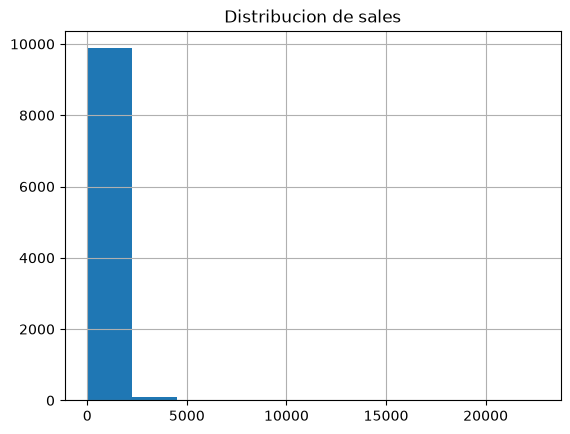

In [58]:
df["Sales"].hist()
plt.title("Distribucion de sales")
plt.show()

### Distribución de las ventas

La variable `Sales` presenta una distribución fuertemente sesgada hacia la
derecha. La mayoría de las observaciones se concentran en valores de venta
relativamente bajos, mientras que existe un pequeño número de registros con
ventas considerablemente mayores.

Estos valores elevados podrían representar valores atípicos (outliers);
sin embargo, no deben considerarse errores automáticamente, ya que podrían
corresponder a transacciones legítimas de alto valor.

Será necesario analizar estos registros antes de decidir si requieren algún
tratamiento.

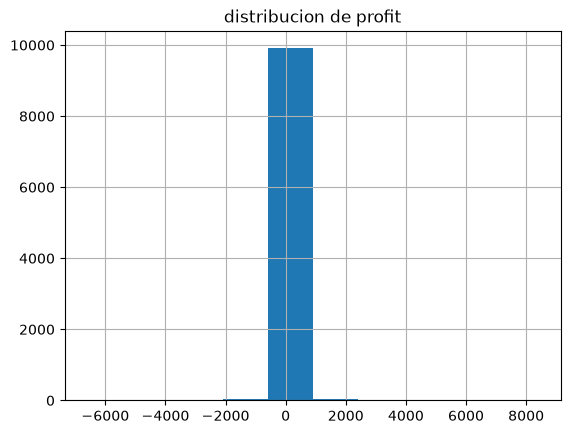

In [59]:
df["Profit"].hist()
plt.title("distribucion de profit")
plt.show()


La distribución de Profit muestra una fuerte concentración de observaciones alrededor de cero, además de valores extremos tanto negativos como positivos. A diferencia de Sales, Profit puede tomar valores negativos, lo que indica que algunas operaciones generaron pérdidas. Sin embargo, el histograma por sí solo no permite determinar qué proporción de las operaciones es rentable o genera pérdidas. Será necesario cuantificar ambos grupos e investigar los valores extremos antes de generar conclusiones.

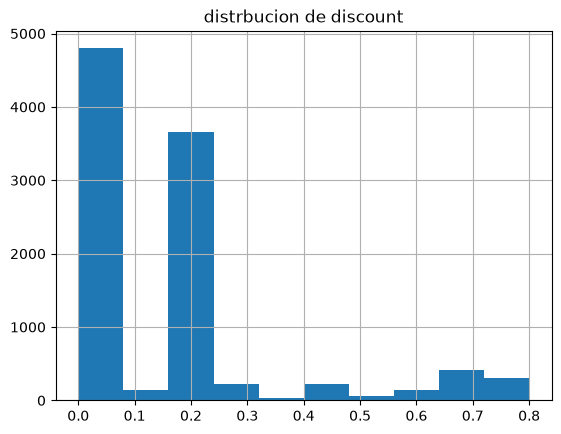

In [60]:
df["Discount"].hist()
plt.title("distrbucion de discount")
plt.show()

Se observa que una proporción importante de las operaciones presenta algún nivel de descuento, destacando especialmente las operaciones sin descuento y aquellas cercanas al 20%. También existen descuentos considerablemente mayores, llegando hasta aproximadamente el 80%.

Este comportamiento plantea la hipótesis de que los descuentos podrían estar relacionados con la rentabilidad de las operaciones. Por ello, sería conveniente analizar qué productos y categorías reciben mayores descuentos y evaluar si los niveles elevados de descuento están asociados con una mayor frecuencia de operaciones con pérdidas.

Con la información disponible todavía no es posible concluir que los clientes compren principalmente debido a los descuentos ni que estos sean la causa directa de las pérdidas.

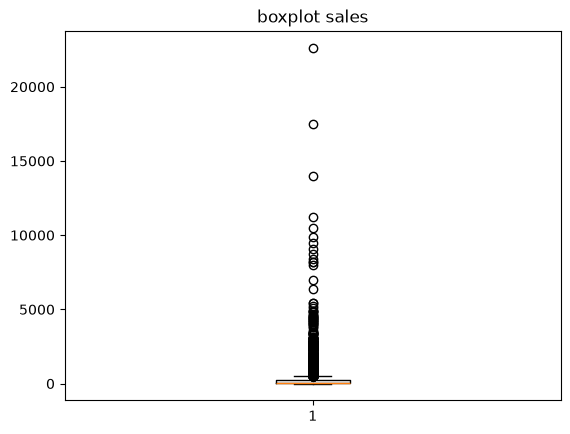

In [61]:
plt.boxplot(df["Sales"])
plt.title("boxplot sales") 
plt.show()

### Análisis de valores atípicos en Sales

El boxplot de la variable `Sales` muestra una distribución con una alta 
concentración de observaciones en valores relativamente bajos y la presencia 
de numerosos valores por encima del límite superior del diagrama.

Estos registros son identificados estadísticamente como posibles valores 
atípicos debido a que se encuentran alejados del rango intercuartílico de 
la distribución. Se observan incluso algunas operaciones con valores de 
venta considerablemente superiores al comportamiento habitual del dataset.

Sin embargo, estos valores no deben eliminarse automáticamente. En un contexto
comercial, una venta elevada puede representar una transacción legítima, como
la compra de productos de alto valor o pedidos con mayores cantidades.

Por este motivo, los valores atípicos serán conservados inicialmente y se 
analizarán considerando otras variables como `Product Name`, `Category`,
`Quantity`, `Discount` y `Profit`.

Este análisis permitirá determinar si los valores extremos corresponden a
errores de calidad de datos o a operaciones comerciales reales y relevantes
para el negocio.

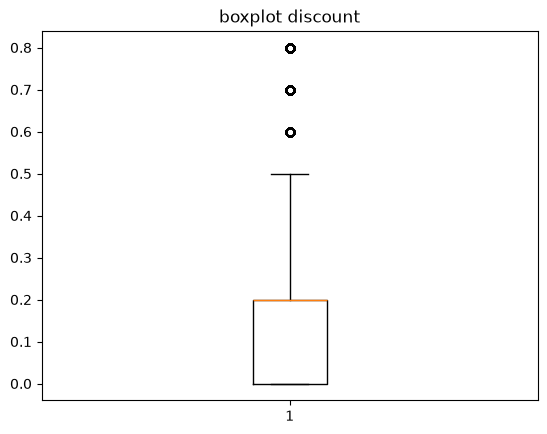

In [62]:
plt.boxplot(df["Discount"])
plt.title("boxplot discount")
plt.show()

### Análisis de valores atípicos en Discount

El boxplot de `Discount` muestra que gran parte de las observaciones se
concentra entre descuentos del 0% y 20%. También se identifican niveles
de descuento considerablemente mayores, particularmente del 60%, 70%
y 80%, que son señalados por el boxplot como posibles valores atípicos.

Sin embargo, estos valores no serán eliminados únicamente por su
clasificación estadística como outliers. Al tratarse de una variable
comercial, los descuentos elevados pueden corresponder a políticas
promocionales reales y representar información relevante para el análisis.

La presencia de descuentos de hasta 80% plantea la hipótesis de que los
niveles elevados de descuento podrían estar relacionados con una reducción
en la rentabilidad de determinadas operaciones.

Por ello, se conservarán estos registros y posteriormente se analizará la
relación entre `Discount` y `Profit`, así como las categorías y productos
en los que se concentran los mayores descuentos.

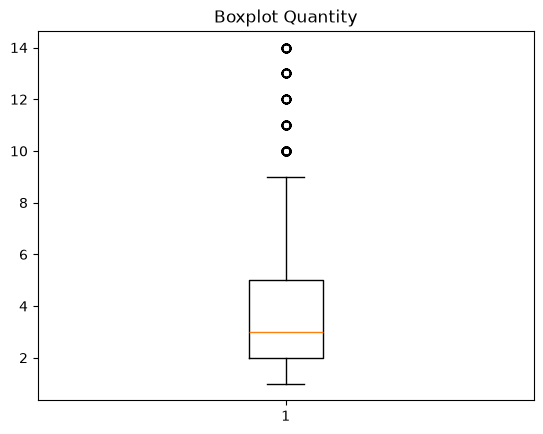

In [63]:
plt.boxplot(df["Quantity"])
plt.title("Boxplot Quantity")  
plt.show()

### Análisis de valores atípicos en Quantity

El boxplot de `Quantity` muestra que el 50% central de las observaciones
se concentra aproximadamente entre 2 y 5 unidades, con una mediana
cercana a 3 unidades por registro.

Se identifican como posibles valores atípicos las operaciones con
cantidades superiores a 9 unidades, observándose registros de hasta
14 unidades.

Sin embargo, estos valores no presentan evidencia suficiente para
considerarse errores, ya que pueden corresponder a compras legítimas
de mayores cantidades.

Por este motivo, los registros serán conservados para análisis posteriores.
Además, podría ser relevante investigar si las compras de mayor volumen
presentan diferencias en ventas, descuentos y rentabilidad.

In [65]:
df[["Sales","Profit","Discount","Quantity"]].corr()

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479064,-0.028190,0.200795
Profit,0.479064,1.000000,-0.219487,0.066253
Discount,-0.028190,-0.219487,1.000000,0.008623
Quantity,0.200795,0.066253,0.008623,1.000000


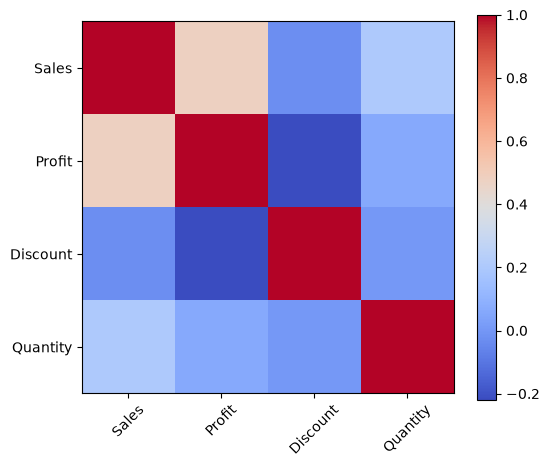

In [ ]:

corr=df[["Sales","Profit","Discount","Quantity"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr,cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)

plt.show()

La matriz de correlación muestra una relación positiva moderada entre
`Sales` y `Profit`, lo que indica que las operaciones con mayores ventas
tienden a presentar mayores beneficios, aunque la relación no es perfecta.

Por otro lado, se observa una relación negativa entre `Discount` y
`Profit`. Esto proporciona evidencia inicial de que los descuentos más
elevados podrían estar asociados con una reducción de la rentabilidad.

Las relaciones de `Quantity` con las demás variables son relativamente
débiles, por lo que la cantidad de unidades vendidas por sí sola no parece
explicar de forma importante las variaciones observadas en rentabilidad.

Estos resultados son correlaciones y no implican causalidad. Se requiere
un análisis adicional por nivel de descuento, producto y categoría para
comprender mejor los factores asociados con las pérdidas.

In [68]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [69]:
df["Region"].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [70]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [71]:
df["Segment"].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [72]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s